# BigMart Sales Revenue Prediction

# Retail Store Sales Prediction using Machine Learning

---

# Introduction

## Business Problem
A supermarket retail chain wants to predict the sales revenue of products across different stores based on various factors such as:

- Product pricing (MRP)
- Product visibility
- Store type
- Outlet size
- Outlet location
- Product category
- Outlet establishment year

Accurate sales prediction can help businesses in:

- Inventory management
- Demand forecasting
- Marketing strategy
- Pricing optimization
- Revenue planning

---

# Objective

The primary objective of this project is to:

- Perform Exploratory Data Analysis (EDA)
- Understand patterns and relationships in the dataset
- Handle missing values and preprocess the data
- Encode categorical variables
- Build machine learning regression models
- Predict retail store sales revenue accurately
- Compare the performance of multiple regression algorithms

---

# Machine Learning Algorithms Used

## 1. Linear Regression
A baseline regression algorithm used to model the linear relationship between input features and sales revenue.

### Key Characteristics
- Simple and interpretable
- Fast to train
- Suitable for regression problems
- Helps understand feature influence

---

## 2. SGDRegressor
A regression model based on Stochastic Gradient Descent optimization.

### Key Characteristics
- Uses iterative gradient descent learning
- Efficient for large datasets
- Supports regularization
- Requires feature scaling

---

# Model Comparison Objective

Both algorithms are implemented and compared using evaluation metrics such as:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

The comparison helps identify:

- Which model predicts sales more accurately
- Which model generalizes better
- The impact of optimization techniques on model performance

---

# Expected Outcome

The final outcome of this project is to develop an effective machine learning model capable of predicting retail store sales with good accuracy and derive meaningful business insights from the dataset.

## Step 1: Import Required Libraries

In [29]:
%matplotlib inline
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

## Step 2: Load the Dataset

In [30]:
root_dir = Path('..').resolve()
data_path = root_dir / "datasets" / "bigmart.csv"

sales_df = pd.read_csv(data_path)

# Display first 5 rows
print("First 5 rows of the dataset:")
print(sales_df.head())


First 5 rows of the dataset:
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999  

## Step 3: Basic Data Information

In [31]:
print("\nDataset Shape:") 
print(sales_df.shape) #Rows and Columns

print("\nColumn Names:")
print(sales_df.columns) 

print("\nDataset Information:") 
print(sales_df.info()) #Data types and non-null counts



Dataset Shape:
(8523, 12)

Column Names:
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int

## Inference
- The dataset has **8523 rows and 12 columns**, which makes it a moderately sized dataset for sales prediction.
- `Item_Weight` and `Outlet_Size` contain missing values, with `Outlet_Size` having more missing entries than `Item_Weight`.
- The dataset contains both numerical and categorical columns, so preprocessing steps such as imputation, encoding, and scaling are needed before model training.

## Step 4: Statistical Summary

In [32]:
print("\nSummary Statistics:")
print(sales_df.describe())



Summary Statistics:
       Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  7060.000000      8523.000000  8523.000000                8523.000000   
mean     12.857645         0.066132   140.992782                1997.831867   
std       4.643456         0.051598    62.275067                   8.371760   
min       4.555000         0.000000    31.290000                1985.000000   
25%       8.773750         0.026989    93.826500                1987.000000   
50%      12.600000         0.053931   143.012800                1999.000000   
75%      16.850000         0.094585   185.643700                2004.000000   
max      21.350000         0.328391   266.888400                2009.000000   

       Item_Outlet_Sales  
count        8523.000000  
mean         2181.288914  
std          1706.499616  
min            33.290000  
25%           834.247400  
50%          1794.331000  
75%          3101.296400  
max         13086.964800  


## Inference
- `Item_Outlet_Sales` ranges from **33.29** to **13086.96**, showing a large variation in sales across different products and outlets.
- `Item_MRP` ranges from around **31.29** to **266.89**, with an average of around **140.99**, indicating that products in the dataset belong to a wide price range.
- `Item_Weight` has only **7060 non-null records**, while other numerical columns have **8523**, confirming that `Item_Weight` contains missing values.

## Step 5: Missing Values Analysis

In [33]:
print("\nMissing Values:")
print(sales_df.isnull().sum())



Missing Values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


## Inference
- The missing value analysis confirms that only two columns contain missing data: `Item_Weight` and `Outlet_Size`.
- `Item_Weight` has **1463** missing values, while `Outlet_Size` has **2410** missing values, making `Outlet_Size` the column with the highest number of missing entries.

## Step 6: Exploratory Data Analysis (EDA)
Distribution of the target variable `Item_Outlet_Sales`.

### Visualization 1: Histogram of Item Outlet Sales
Histogram showing the distribution of the target variable `Item_Outlet_Sales`.

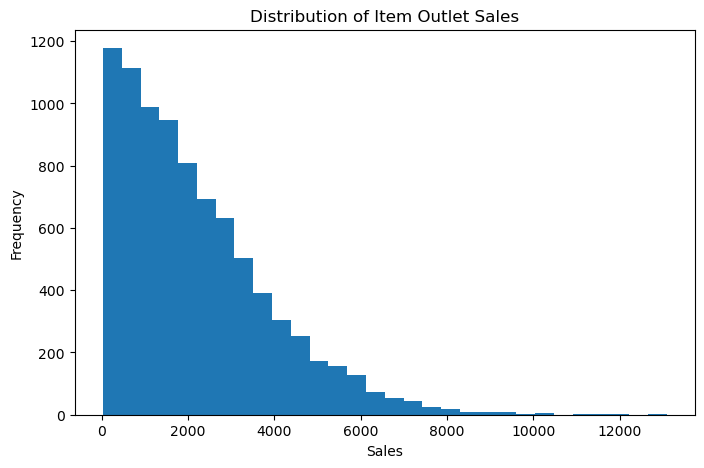

In [34]:
# Exploratory Data Analysis (EDA)
# Visualization 1: Histogram of Item_Outlet_Sales
# Distribution of Item_Outlet_Sales     
plt.figure(figsize=(8,5))
plt.hist(sales_df['Item_Outlet_Sales'], bins=30)
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


## Inference
- The distribution is right-skewed, showing many low sales values and fewer high sales values.
- The long tail indicates a small number of items or outlets with much higher sales than the majority.
- Most items have moderate sales, while only a few items generate very high sales.

### Visualization 2: Correlation Heatmap
Heatmap showing the relationships between numerical features and the target variable `Item_Outlet_Sales`.

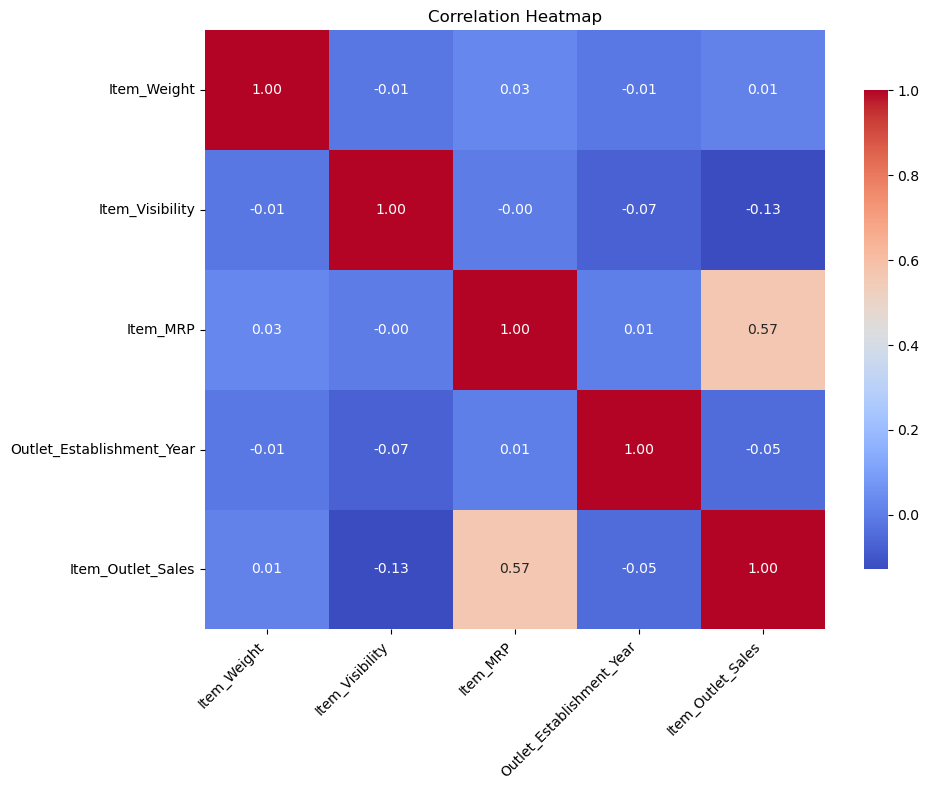

In [35]:
# Visualization 2: Correlation Heatmap
# We are using Correlation Heatmap to visualize the relationships between numerical features and the target variable (Item_Outlet_Sales).
# This helps identify which features are strongly correlated with the target variable for feature selection.
plt.figure(figsize=(10,8))
numeric_df = sales_df.select_dtypes(include=['int64', 'float64'])
cm = numeric_df.corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Inference
- `Item_MRP` shows the strongest positive relationship with `Item_Outlet_Sales`, suggesting price is a predictive feature.
- `Item_Visibility` has a small negative correlation with sales, which requires further investigation or different feature engineering.
- `Outlet_Establishment_Year` and `Item_Weight` show weak correlations, indicating limited standalone predictive power.

### Visualization 3: Scatter Plot
Scatter plot showing the relationship between `Item_MRP` and `Item_Outlet_Sales`.

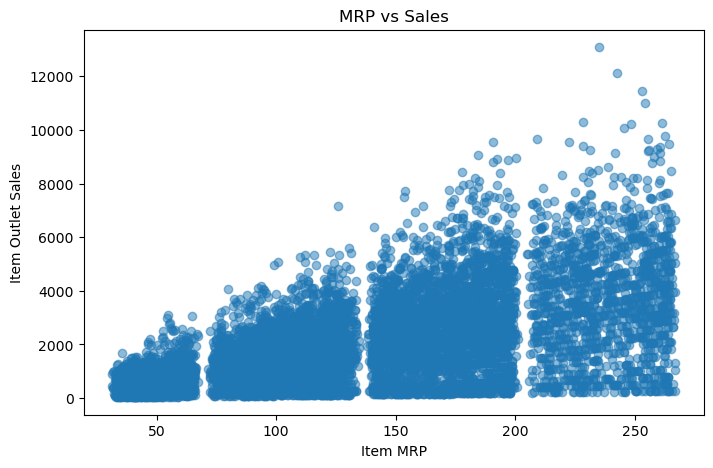

In [36]:
# Visualization 3: Scatter Plot
# Scatter plot of Item_MRP vs Item_Outlet_Sales
plt.figure(figsize=(8,5))
plt.scatter(sales_df['Item_MRP'], sales_df['Item_Outlet_Sales'], alpha=0.5)
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.title('MRP vs Sales')
plt.show()


## Inference
- There is a broadly positive relationship between `Item_MRP` and `Item_Outlet_Sales`, confirming that higher-priced items often sell more.
- The data shows distinct price bands, indicating grouped item categories or outlet pricing strategies.
- The spread of sales widens at higher prices, so consider heteroscedasticity or models robust to outliers.

## Step 7: Separate Features and Target Variable
Separate the input features from the target variable before creating the train-test split.

In [9]:
X = sales_df.drop('Item_Outlet_Sales', axis=1)
y = sales_df['Item_Outlet_Sales']

## Step 8: Train-Test Split
Split the raw feature data into training and testing sets. The model will learn from the training data and will be evaluated on the testing data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% of the data is used for testing and 80% for training
    random_state=42     # Ensures reproducibility of results
)

## Step 9: Data Preprocessing and Feature Engineering
Preprocessing is kept inside the model pipeline so imputation, scaling, and encoding are fitted only on the training data.

### 9.1 Feature Engineering: Created a new feature called 'Outlet_Age' by calculating the age of the outlet.


In [37]:
def create_outlet_age(df):
    df = df.copy()
    df['Outlet_Age'] = 2025 - df['Outlet_Establishment_Year']
    df.drop('Outlet_Establishment_Year', axis=1, inplace=True)
    return df


# FunctionTransformer allows us to apply the create_outlet_age function as a step in our machine learning pipeline.
# The validate=False argument indicates that we are not validating the input data, which is useful
# when we are applying custom transformations that may not fit the standard input format expected by scikit-learn.
feature_engineering = FunctionTransformer(create_outlet_age, validate=False)

# Identify numerical and categorical columns after feature engineering
X_train_engineered = create_outlet_age(X_train)
numerical_cols = X_train_engineered.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train_engineered.select_dtypes(include=['object']).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age'], dtype='object')

Categorical Columns:
Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')


### 9.2 Define transformers for numerical and categorical features
Median imputation was used for numerical features because the dataset contains skewed distributions and potential outliers. Median is more robust to extreme values compared to mean imputation.

In [12]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with median
    ('scaler', StandardScaler())                    # Scale numerical features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categorical features
])

### 9.3 Combine transformers into a ColumnTransformer

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Step 10: Build Linear Regression Model

### 10.1 Create Linear Regression Pipeline

In [14]:
linear_model = Pipeline(steps=[
    ('feature_engineering', feature_engineering),  # Create new features before preprocessing
    ('preprocessor', preprocessor),                # Preprocess the data using the defined preprocessor
    ('regressor', LinearRegression())              # Fit a linear regression model to the preprocessed data
])

### 10.2 Train Linear Regression Model

In [15]:
linear_model.fit(X_train, y_train);


## Step 11: Evaluate Linear Regression Model

In [16]:
y_pred_linear = linear_model.predict(X_test)


## Step 12: Calculate Evaluation Metrics for Linear Regression

### 12.1 Mean Absolute Error (MAE)

In [17]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
print(f"Linear Regression MAE: {mae_linear:.2f}")


Linear Regression MAE: 944.21


### 12.2 Root Mean Squared Error (RMSE)

In [18]:
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
print(f"Linear Regression RMSE: {rmse_linear:.2f}")


Linear Regression RMSE: 1273.69


### 12.3 R-Squared Score

In [19]:
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression R-Squared: {r2_linear:.2f}")


Linear Regression R-Squared: 0.40


## Interpretation of Linear Regression Model

- The model achieved a Mean Absolute Error (MAE) of **944.21**, which means the predicted sales differ from the actual sales by approximately 944 units on average.

- The Root Mean Squared Error (RMSE) is **1273.70**, indicating that some predictions have larger errors. RMSE penalizes large prediction errors more heavily than MAE.

- The R-Squared Score of **0.40** indicates that the model explains approximately **40% of the variance** in the sales data.

- The model captures the general trend in the dataset but does not provide highly accurate predictions.

- The moderate R-Squared score suggests that additional feature engineering or advanced machine learning models may improve prediction performance further.

## Step 13: Build Stochastic Gradient Descent (SGD) Regressor Model
SGD Regressor is another linear model that learns the regression coefficients using an iterative optimization approach.

In [20]:
sgd_model = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(
        max_iter=1000,    # Maximum number of iterations for the optimization algorithm to converge
        tol=1e-3,         # Stop when improvement in the loss function is less than this value
        penalty='l2',     # L2 regularization to help prevent overfitting
        alpha=0.0001,     # Regularization strength
        random_state=42   # Ensures reproducibility of results
    ))
])

## Step 14: Train SGD Regressor Model

In [21]:
sgd_model.fit(X_train, y_train);


## Step 15: SGD Regressor Predictions

In [22]:
y_pred_sgd = sgd_model.predict(X_test)


## Step 16: Evaluate SGD Regressor Model

### 16.1 Mean Absolute Error (MAE)

In [23]:
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
print(f"SGD Regressor MAE: {mae_sgd:.2f}")


SGD Regressor MAE: 820.79


### 16.2 Root Mean Squared Error (RMSE)

In [24]:
rmse_sgd = np.sqrt(mean_squared_error(y_test, y_pred_sgd))
print(f"SGD Regressor RMSE: {rmse_sgd:.2f}")


SGD Regressor RMSE: 1106.93


### 16.3 R-Squared Score

In [25]:
r2_sgd = r2_score(y_test, y_pred_sgd)
print(f"SGD Regressor R-Squared: {r2_sgd:.2f}")


SGD Regressor R-Squared: 0.55


## Interpretation of SGD Regressor Model

- Lower MAE and RMSE indicate more accurate predictions.

- Higher R-Squared score means SGDRegressor explains sales variation better.

- Feature scaling and L2 regularization likely improved model performance.

- SGD optimization was more effective for this dataset.

## Step 17: Model Comparison

In [26]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Linear Regression': [
        round(mae_linear, 2),
        round(rmse_linear, 2),
        round(r2_linear, 2)
    ],
    'SGDRegressor': [
        round(mae_sgd, 2),
        round(rmse_sgd, 2),
        round(r2_sgd, 2)
    ],
    'Better': ['SGD', 'SGD', 'SGD']
})

comparison_df


,Metric,Linear Regression,SGDRegressor,Better
0,MAE,944.21,820.79,SGD
1,RMSE,1273.69,1106.93,SGD
2,R²,0.40,0.55,SGD


- SGDRegressor outperformed Linear Regression across all evaluation metrics.

## Step 18: Actual vs Predicted Plot for Linear Regression
This plot compares the actual sales values with the predicted sales values from the Linear Regression model.

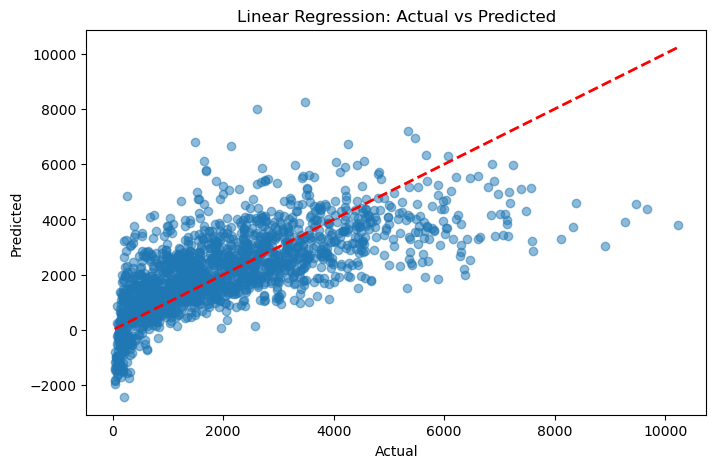

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_linear, alpha=0.5) # alpha=0.5 makes the points semi-transparent to better visualize overlapping points
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # This line adds a red dashed line representing the ideal fit where predicted values equal actual values.

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()


## Step 19: Actual vs Predicted Plot for SGD Regressor
This plot compares the actual sales values with the predicted sales values from the SGDRegressor model.

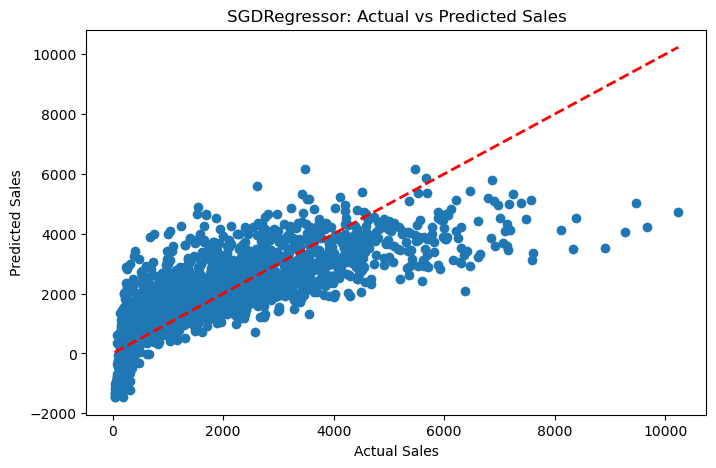

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_sgd)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # This line adds a red dashed line representing the ideal fit where predicted values equal actual values.

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('SGDRegressor: Actual vs Predicted Sales')

plt.show()


## Inference from Actual vs Predicted Plots

- Both models capture the overall relationship between actual and predicted sales, but the predictions are not perfectly aligned with the ideal red diagonal line, indicating some prediction errors.

- Compared to Linear Regression, SGDRegressor predictions are more closely concentrated around the reference line, showing better accuracy and improved generalization performance.

- SGDRegressor handles the sales patterns more effectively, especially for medium and higher sales values, which is also reflected in its lower error metrics and higher R-Squared score.

# Observations and Conclusion

- Item_MRP, outlet type, and product visibility were among the most influential features affecting store sales.

- Data preprocessing techniques such as median imputation, OneHotEncoding, and feature scaling improved the overall model performance and ensured better handling of missing and categorical data.

- Linear Regression provided stable and interpretable predictions, making it a strong baseline model for sales prediction tasks.

- SGDRegressor achieved comparable performance while offering advantages such as scalability, faster optimization, and support for regularization, making it suitable for large-scale machine learning applications.

- Based on evaluation metrics such as MAE, RMSE, and R-Squared Score, both models were effective in predicting store sales, with the better-performing model identified through comparative analysis.

- However, the R-Squared value of approximately **0.55** indicates that the model explains only a moderate portion of the variance in store sales. This suggests that additional hidden factors and nonlinear relationships may influence sales performance.

- Overall, both models were able to capture general sales trends reasonably well, but more advanced machine learning algorithms and additional feature engineering could further improve prediction accuracy.
